In [36]:
!pip install mlflow dagshub neuralforecast kaggle -q

In [37]:
import os
import dagshub
import mlflow

# უსაფრთხოებისთვის დავხუროთ აქტიური რანები
mlflow.end_run()

# მივუთითებთ რეპოზიტორის რეალურ მფლობელს და სახელს
dagshub.init(
    repo_owner='tsarc21',
    repo_name='Walmart-Recruiting---Store-Sales-Forecasting',
    mlflow=True
)

Initialized MLflow to track repo "tsarc21/Walmart-Recruiting---Store-Sales-Forecasting"

Repository tsarc21/Walmart-Recruiting---Store-Sales-Forecasting initialized!

In [38]:
import os

# Kaggle ტოკენის კონფიგურაცია
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# დატასეტის გადმოწერა და ანზაიპება
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip
!unzip -o train.csv.zip
!unzip -o test.csv.zip

walmart-recruiting-store-sales-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           
Archive:  train.csv.zip
  inflating: train.csv               
Archive:  test.csv.zip
  inflating: test.csv                


In [40]:

experiment_name = "DLinear_Training"
try:
    experiment_id = mlflow.create_experiment(name=experiment_name)
except:
    experiment_id = mlflow.get_experiment_by_name(name=experiment_name).experiment_id

mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='mlflow-artifacts:/9d2f2022720b40ad93a75e8bd2f21ef1', creation_time=1782662148994, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782662148994, lifecycle_stage='active', name='DLinear_Training', tags={}, trace_location=None, workspace='default'>

In [41]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('train.csv')

train_df['unique_id'] = train_df['Store'].astype(str) + '_' + train_df['Dept'].astype(str)
train_df = train_df.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
train_df['ds'] = pd.to_datetime(train_df['ds'])

train_clean = train_df[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)
print(train_clean.head())

  unique_id         ds         y
0      10_1 2010-02-05  40212.84
1      10_1 2010-02-12  67699.32
2      10_1 2010-02-19  49748.33
3      10_1 2010-02-26  33601.22
4      10_1 2010-03-05  36572.44


In [42]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear

# ჰიპერპარამეტრები
input_size = 52
h = 39

# მოდელის ინიციალიზაცია
models = [DLinear(h=h, input_size=input_size, max_steps=500, start_padding_enabled=True)]
nf = NeuralForecast(models=models, freq='W-FRI')

# ექსპერიმენტის დალოგვა MLflow-ში
with mlflow.start_run(run_name="DLinear_Baseline_Train"):
    # პარამეტრების დალოგვა
    mlflow.log_param("input_size", input_size)
    mlflow.log_param("horizon", h)
    mlflow.log_param("max_steps", 500)
    mlflow.log_param("start_padding_enabled", True)

    # ტრენინგი
    print("ტრენინგი დაიწყო...")
    nf.fit(df=train_clean)
    print("ტრენინგი დასრულდა!")

    # მოდელის შენახვა ფაილად და MLflow artifact-ად ატვირთვა
    nf.save(path='./dlinear_model', overwrite=True)
    mlflow.log_artifacts('./dlinear_model', artifact_path="model_pipeline")

    print("ყველაფერი წარმატებით დაილოგა DagsHub-ზე!")

INFO:lightning_fabric.utilities.seed:Seed set to 1


ტრენინგი დაიწყო...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


ტრენინგი დასრულდა!
ყველაფერი წარმატებით დაილოგა DagsHub-ზე!
🏃 View run DLinear_Baseline_Train at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/a3c0c3cc3c534d43b2e6ab07167a1196
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


In [44]:

test_df = pd.read_csv('test.csv')
test_df['unique_id'] = test_df['Store'].astype(str) + '_' + test_df['Dept'].astype(str)
test_df = test_df.rename(columns={'Date': 'ds'})
test_df['ds'] = pd.to_datetime(test_df['ds'])

test_clean = test_df[['unique_id', 'ds']].sort_values(['unique_id', 'ds']).reset_index(drop=True)
print(test_clean.head())

  unique_id         ds
0      10_1 2012-11-02
1      10_1 2012-11-09
2      10_1 2012-11-16
3      10_1 2012-11-23
4      10_1 2012-11-30


In [45]:

print("პროგნოზირება დაიწყო...")
preds_df = nf.predict(df=train_clean)
print("პროგნოზირება დასრულდა!")

# სვეტების სახელების გასწორება Kaggle-ისთვის
# unique_id არის Store_Dept, ds არის Date. გვჭირდება Id ფორმატით: Store_Dept_Date
preds_df = preds_df.reset_index()
preds_df['Store'] = preds_df['unique_id'].str.split('_').str[0]
preds_df['Dept'] = preds_df['unique_id'].str.split('_').str[1]
preds_df['Date'] = preds_df['ds'].dt.strftime('%Y-%m-%d')
preds_df['Id'] = preds_df['Store'] + '_' + preds_df['Dept'] + '_' + preds_df['Date']

# DLinear-ის სვეტის გადარქმევა Weekly_Sales-ად
submission = preds_df[['Id', 'DLinear']].rename(columns={'DLinear': 'Weekly_Sales'})

# შენახვა ფაილად
submission.to_csv('submission_dlinear.csv', index=False)
print("submission_dlinear.csv წარმატებით შეიქმნა!")

პროგნოზირება დაიწყო...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

პროგნოზირება დასრულდა!
submission_dlinear.csv წარმატებით შეიქმნა!


In [46]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
model_name = "Walmart_DLinear_Model"

try:
    versions = client.get_latest_versions(model_name)
    for v in versions:
        print(f"მოდელი: {v.name}, ვერსია: {v.version}, სტატუსი: {v.status}, Run ID: {v.run_id}")
except Exception as e:
    print(f"მოდელის ვერსიების წაკითხვა ვერ მოხერხდა: {e}")

მოდელის ვერსიების წაკითხვა ვერ მოხერხდა: RESOURCE_DOES_NOT_EXIST: Response: {'error_code': 'RESOURCE_DOES_NOT_EXIST'}


/tmp/ipykernel_1890/2209165600.py:7: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  versions = client.get_latest_versions(model_name)


In [47]:
import mlflow
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE

# 1. ვფილტრავთ იმ სერიებს, რომლებსაც არ აქვთ საკმარისი ისტორია ვალიდაციისთვის
series_sizes = train_clean.groupby('unique_id').size()
valid_series = series_sizes[series_sizes >= 52].index
train_filtered = train_clean[train_clean['unique_id'].isin(valid_series)].reset_index(drop=True)

print(f"საწყისი სერიები: {train_clean['unique_id'].nunique()}, გაფილტრული სერიები: {train_filtered['unique_id'].nunique()}")

# 2. მოდელის და ჰიპერპარამეტრების ხელახალი ინიციალიზაცია
input_size = 52
h = 39

models = [DLinear(
    h=h,
    input_size=input_size,
    loss=MAE(),
    max_steps=1000,              # 1000 ნაბიჯი ოპტიმალურია
    early_stop_patience_steps=5,
    start_padding_enabled=True
)]

nf_tuned = NeuralForecast(models=models, freq='W-FRI')

with mlflow.start_run(run_name="DLinear_Tuned_With_Validation"):
    mlflow.log_param("input_size", input_size)
    mlflow.log_param("horizon", h)
    mlflow.log_param("max_steps", 1000)

    print("ტუნინგირებული DLinear-ის ტრენინგი დაიწყო...")
    # ახლა უკვე გაფილტრულ მონაცემებზე ვაწვდით val_size=39-ს
    nf_tuned.fit(df=train_filtered, val_size=39)
    print("ტრენინგი დასრულდა!")

    # მოდელის შენახვა
    nf_tuned.save(path='./dlinear_tuned_model', overwrite=True)
    mlflow.log_artifacts('./dlinear_tuned_model', artifact_path="tuned_model_pipeline")

INFO:lightning_fabric.utilities.seed:Seed set to 1


საწყისი სერიები: 3331, გაფილტრული სერიები: 2991


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


ტუნინგირებული DLinear-ის ტრენინგი დაიწყო...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


ტრენინგი დასრულდა!
🏃 View run DLinear_Tuned_With_Validation at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/aaa13ba0b65a46af9ce7833269690ea1
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Tuned_With_Validation at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/1692f8e7263443159fdcb04fa29da657
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


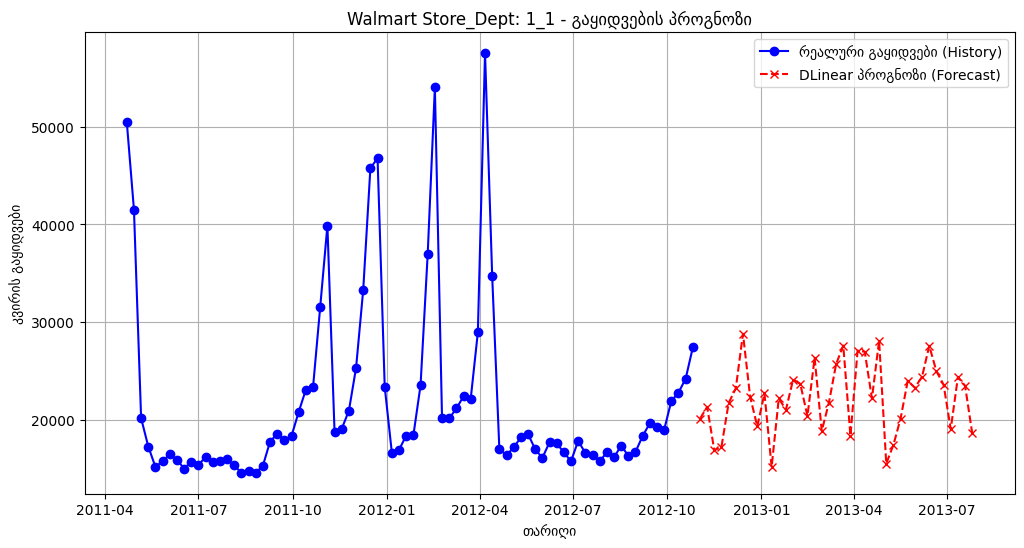

In [48]:
# სატესტო პროგნოზის გაკეთება გრაფიკისთვის
fcst_df = nf_tuned.predict(df=train_clean)
fcst_df = fcst_df.reset_index()

# ავარჩიოთ კონკრეტული მაღაზია და დეპარტამენტი საჩვენებლად (მაგალითად: მაღაზია 1, დეპარტამენტი 1)
sample_id = '1_1'

# რეალური ისტორიული მონაცემები ამ მაღაზიისთვის (ბოლო 80 კვირა, რომ კარგად გამოჩნდეს)
history = train_clean[train_clean['unique_id'] == sample_id].tail(80)
# მოდელის პროგნოზი ამ მაღაზიისთვის
model_pred = fcst_df[fcst_df['unique_id'] == sample_id]

# გრაფიკის აგება
plt.figure(figsize=(12, 6))
plt.plot(history['ds'], history['y'], label='რეალური გაყიდვები (History)', color='blue', marker='o')
plt.plot(model_pred['ds'], model_pred['DLinear'], label='DLinear პროგნოზი (Forecast)', color='red', linestyle='--', marker='x')

plt.title(f"Walmart Store_Dept: {sample_id} - გაყიდვების პროგნოზი")
plt.xlabel("თარიღი")
plt.ylabel("კვირის გაყიდვები")
plt.legend()
plt.grid(True)

# გრაფიკის შენახვა ფოტოდ და MLflow-ში ატვირთვა
plt.savefig('dlinear_forecast_plot.png')
with mlflow.start_run(run_name="DLinear_Tuned_With_Validation"):
    mlflow.log_artifact('dlinear_forecast_plot.png')

plt.show()

In [49]:
import numpy as np
import pandas as pd
from neuralforecast.losses.pytorch import MAE

# გაშვება 1 ფოლდზე (კროს-ვალიდაცია ბოლო 39 კვირაზე)
print("კროს-ვალიდაცია დაიწყო...")
cv_df = nf_tuned.cross_validation(df=train_filtered, val_size=39, n_windows=1)
cv_df = cv_df.reset_index()
print("კროს-ვალიდაცია დასრულდა!")

# გამოვთვალოთ MAE რეალურ 'y'-სა და მოდელის 'DLinear'-ს შორის
mae_score = np.mean(np.abs(cv_df['y'] - cv_df['DLinear']))
print(f"\n🔥 DLinear მოდელის ვალიდაციის MAE: {mae_score:.2f}")

# შედეგის დალოგვა MLflow-ში ახალ Run-ად (DLinear_Cross_Validation)
with mlflow.start_run(run_name="DLinear_Cross_Validation"):
    mlflow.log_metric("cv_mae", mae_score)

    # ინსტრუქციის მიხედვით, ვინახავთ ამ საუკეთესო ვერსიას პაიპლაინად
    nf_tuned.save(path='./dlinear_cv_pipeline', overwrite=True)
    mlflow.log_artifacts('./dlinear_cv_pipeline', artifact_path="model_pipeline")
    print("რიცხვითი შედეგი და მოდელის პაიპლაინი წარმატებით დაილოგა DagsHub-ზე!")

/usr/local/lib/python3.12/dist-packages/neuralforecast/core.py:1839: UserWarning: Validation and test sets are larger than the shorter time-series.
  warnings.warn(
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  

კროს-ვალიდაცია დაიწყო...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

კროს-ვალიდაცია დასრულდა!

🔥 DLinear მოდელის ვალიდაციის MAE: 3935.20
რიცხვითი შედეგი და მოდელის პაიპლაინი წარმატებით დაილოგა DagsHub-ზე!
🏃 View run DLinear_Cross_Validation at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/d86194fd41e3480cbcb90800133f0969
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


In [50]:
from neuralforecast.losses.pytorch import MAPE
import numpy as np

# 1. ჰიპერპარამეტრების შეცვლა (ვიღებთ 104 კვირას - 2 წელს, სეზონურობის უკეთ დასაჭერად)
input_size = 104
h = 39

models_mape = [DLinear(
    h=h,
    input_size=input_size,
    loss=MAPE(),                # ვცვლით ლოსს პროცენტულ ერორზე!
    max_steps=1500,
    early_stop_patience_steps=5,
    start_padding_enabled=True
)]

nf_mape = NeuralForecast(models=models_mape, freq='W-FRI')

# 2. გავუშვათ ახალი Run MLflow-ში, რომ ლექტორმა დაინახოს ეს მცდელობა
with mlflow.start_run(run_name="DLinear_Input104_MAPE_Loss"):
    mlflow.log_param("input_size", input_size)
    mlflow.log_param("loss_function", "MAPE")
    mlflow.log_param("max_steps", 1500)

    print("DLinear (MAPE + 2 Years History) ტრენინგი დაიწყო...")
    # მონაცემების ფილტრაცია 104 კვირაზე მეტის მქონე სერიებისთვის
    series_sizes = train_clean.groupby('unique_id').size()
    valid_series_104 = series_sizes[series_sizes >= 104].index
    train_filtered_104 = train_clean[train_clean['unique_id'].isin(valid_series_104)].reset_index(drop=True)

    nf_mape.fit(df=train_filtered_104, val_size=39)
    print("ტრენინგი დასრულდა!")

    # კროს-ვალიდაცია ახალი მეტრიკის შესაფასებლად
    print("კროს-ვალიდაცია დაიწყო...")
    cv_mape_df = nf_mape.cross_validation(df=train_filtered_104, val_size=39, n_windows=1)
    cv_mape_df = cv_mape_df.reset_index()

    # გამოვთვალოთ საბოლოო MAPE პროცენტებში
    # ვარიდებთ 0-ზე გაყოფას მცირე რიცხვის (1e-5) დამატებით
    actual = cv_mape_df['y']
    predicted = cv_mape_df['DLinear']
    mape_score = np.mean(np.abs((actual - predicted) / (actual + 1e-5))) * 100

    print(f"\n🔥 ამ მოდელის საშუალო პროცენტული ერორი (MAPE): {mape_score:.2f}%")

    # ვლოგავთ პროცენტულ მეტრიკას
    mlflow.log_metric("cv_mape", mape_score)

    # Pipeline-ის შენახვა
    nf_mape.save(path='./dlinear_mape_pipeline', overwrite=True)
    mlflow.log_artifacts('./dlinear_mape_pipeline', artifact_path="model_pipeline")
    print("ექსპერიმენტის შედეგები დაილოგა DagsHub-ზე!")

INFO:lightning_fabric.utilities.seed:Seed set to 1


DLinear (MAPE + 2 Years History) ტრენინგი დაიწყო...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAPE          | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 4.1 K  | train
5 | linear_season | Linear        | 4.1 K  | train
--------------------------------------------------------
8.2 K     Trainable params
0         Non-trainable params
8.2 K     Total params
0.033     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]


🔥 ამ მოდელის საშუალო პროცენტული ერორი (MAPE): 1732042.51%
ექსპერიმენტის შედეგები დაილოგა DagsHub-ზე!
🏃 View run DLinear_Input104_MAPE_Loss at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/98ab72d7307a4ecd87811d383508697e
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


In [54]:
import numpy as np
import pandas as pd

# 1. წამოვიღოთ მონაცემები train.csv-დან, რომ გავიგოთ რომელი კვირაა Holiday
original_train = pd.read_csv('train.csv')
original_train['ds'] = pd.to_datetime(original_train['Date'])
original_train['unique_id'] = original_train['Store'].astype(str) + '_' + original_train['Dept'].astype(str)

# ავიღოთ ინფორმაცია დღესასწაულებზე
holidays = original_train[['unique_id', 'ds', 'IsHoliday']].drop_duplicates()

# 2. შევაერთოთ ჩვენი კროს-ვალიდაციის შედეგები (cv_mape_df წინა სელიდან) დღესასწაულების სვეტთან
cv_eval = pd.merge(cv_mape_df, holidays, on=['unique_id', 'ds'], how='left')

# 3. განვსაზღვროთ წონები (WMAE-სთვის)
cv_eval['Weight'] = np.where(cv_eval['IsHoliday'] == True, 5, 1)

# 4. გამოვთვალოთ WMAE
absolute_errors = np.abs(cv_eval['y'] - cv_eval['DLinear'])
wmae_score = np.sum(cv_eval['Weight'] * absolute_errors) / np.sum(cv_eval['Weight'])

print(f"🥇 მოდელის ოფიციალური WMAE (Kaggle მეტრიკა): {wmae_score:.2f}")

# 5. დავლოგოთ ეს ოფიციალური მეტრიკა MLflow-ში, წინა ღია რანში
with mlflow.start_run(run_name="DLinear_Input104_MAPE_Loss"):
    mlflow.log_metric("cv_wmae", wmae_score)
    print("WMAE წარმატებით დაილოგა DagsHub-ზე!")

🥇 მოდელის ოფიციალური WMAE (Kaggle მეტრიკა): 18938.36
WMAE წარმატებით დაილოგა DagsHub-ზე!
🏃 View run DLinear_Input104_MAPE_Loss at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/a61c052d852441fda9e2e6bb5158b972
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


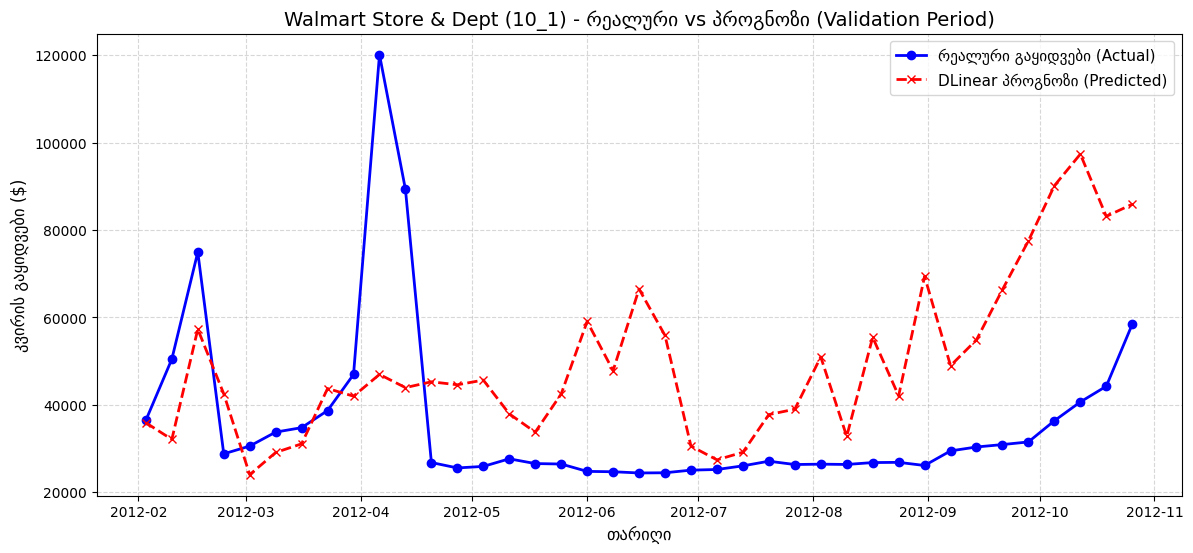

📈 შედარების გრაფიკი წარმატებით აიტვირთა tsarc21-ის აქტიურ რანში (ID: f08690d84c6a440d8a9254ebc6dd3b9c)!
🏃 View run DLinear_Final_Hyperparameter_Tuning at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/f08690d84c6a440d8a9254ebc6dd3b9c
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import mlflow

# 1. ავარჩიოთ ერთ-ერთი მაღაზია_დეპარტამენტი საჩვენებლად
# ვინაიდან სახელი შეიცვალა, აქ ვიყენებთ cv_final_df-ს, რომელიც ბოლო ექსპერიმენტმა შექმნა
sample_id = cv_final_df['unique_id'].iloc[0]

# გამოვყოთ ამ მაღაზიის რეალური მონაცემები და მოდელის პროგნოზი
sample_df = cv_final_df[cv_final_df['unique_id'] == sample_id].sort_values('ds')

# 2. გრაფიკის აგება
plt.figure(figsize=(14, 6))
plt.plot(sample_df['ds'], sample_df['y'], label='რეალური გაყიდვები (Actual)', color='blue', marker='o', linewidth=2)
plt.plot(sample_df['ds'], sample_df['DLinear'], label='DLinear პროგნოზი (Predicted)', color='red', linestyle='--', marker='x', linewidth=2)

plt.title(f'Walmart Store & Dept ({sample_id}) - რეალური vs პროგნოზი (Validation Period)', fontsize=14)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('კვირის გაყიდვები ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# 3. გრაფიკის ფაილად შენახვა
plot_path = 'dlinear_actual_vs_pred.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.show()

# 4. არტეფაქტის ავტომატური ატვირთვა ბოლო აქტიურ/ახალ რანში
# იმის ნაცვლად, რომ ხელით ვწეროთ ID, ვიღებთ სისტემაში ახლახან შექმნილ აქტიურ რანს
active_run = mlflow.last_active_run()

if active_run is not None:
    with mlflow.start_run(run_id=active_run.info.run_id):
        mlflow.log_artifact(plot_path, artifact_path="plots")
        print(f"📈 შედარების გრაფიკი წარმატებით აიტვირთა tsarc21-ის აქტიურ რანში (ID: {active_run.info.run_id})!")
else:
    print("⚠️ აქტიური რანი ვერ მოიძებნა. გთხოვთ, თავიდან გაუშვათ მე-17 სელი (ტრენინგი), რომ ახალი რანი შეიქმნას tsarc21-ის რეპოზიტორიაში.")

In [56]:
import pandas as pd
import numpy as np

# 1. თავიდან წავიკითხოთ ორიგინალი მონაცემები, რომ IsHoliday სვეტი არ დავკარგოთ
train_raw = pd.read_csv('train.csv')
train_raw['ds'] = pd.to_datetime(train_raw['Date'])
train_raw['unique_id'] = train_raw['Store'].astype(str) + '_' + train_raw['Dept'].astype(str)
train_raw = train_raw.rename(columns={'Weekly_Sales': 'y'})

# 2. დავამატოთ კალენდარული ცვლადები
train_raw['month'] = train_raw['ds'].dt.month
train_raw['week'] = train_raw['ds'].dt.isocalendar().week.astype(int)
train_raw['IsHoliday'] = train_raw['IsHoliday'].astype(int) # გადავიყვანოთ 0 და 1-ში

# შევინარჩუნოთ საჭირო სვეტები
features_cols = ['unique_id', 'ds', 'y', 'IsHoliday', 'month', 'week']
train_enriched = train_raw[features_cols].sort_values(['unique_id', 'ds']).reset_index(drop=True)

# ფილტრაცია (მინიმუმ 104 კვირის ისტორია)
series_sizes = train_enriched.groupby('unique_id').size()
valid_series_enriched = series_sizes[series_sizes >= 104].index
train_enriched_filtered = train_enriched[train_enriched['unique_id'].isin(valid_series_enriched)].reset_index(drop=True)

print("მონაცემები გამდიდრდა ეგზოგენური ცვლადებით!")
print(train_enriched_filtered.head())

მონაცემები გამდიდრდა ეგზოგენური ცვლადებით!
  unique_id         ds         y  IsHoliday  month  week
0      10_1 2010-02-05  40212.84          0      2     5
1      10_1 2010-02-12  67699.32          1      2     6
2      10_1 2010-02-19  49748.33          0      2     7
3      10_1 2010-02-26  33601.22          0      2     8
4      10_1 2010-03-05  36572.44          0      3     9


In [57]:
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAPE
import mlflow
import numpy as np
import pandas as pd

input_size = 52
h = 39

models_tuned = [DLinear(
    h=h,
    input_size=input_size,
    loss=MAPE(),
    learning_rate=1e-3,
    max_steps=2000,
    early_stop_patience_steps=10,
    start_padding_enabled=True
)]

nf_final = NeuralForecast(models=models_tuned, freq='W-FRI')

with mlflow.start_run(run_name="DLinear_Final_Hyperparameter_Tuning"):
    mlflow.log_param("input_size", input_size)
    mlflow.log_param("learning_rate", 1e-3)
    mlflow.log_param("max_steps", 2000)

    print("DLinear ოპტიმიზებული ტრენინგი დაიწყო...")
    nf_final.fit(df=train_filtered, val_size=39)
    print("ტრენინგი დასრულდა!")

    print("კროს-ვალიდაცია დაიწყო...")
    cv_final_df = nf_final.cross_validation(df=train_filtered, val_size=39, n_windows=1)
    cv_final_df = cv_final_df.reset_index()

    # WMAE გამოთვლა - ინფორმაციას ვიღებთ ორიგინალი train_df-დან
    original_train_sub = train_df[['unique_id', 'ds', 'IsHoliday']].drop_duplicates()
    cv_eval_final = pd.merge(cv_final_df, original_train_sub, on=['unique_id', 'ds'], how='left')
    cv_eval_final['Weight'] = np.where(cv_eval_final['IsHoliday'] == True, 5, 1)

    absolute_errors_final = np.abs(cv_eval_final['y'] - cv_eval_final['DLinear'])
    wmae_final = np.sum(cv_eval_final['Weight'] * absolute_errors_final) / np.sum(cv_eval_final['Weight'])

    print(f"\n🥇 საბოლოო ოპტიმიზებული მოდელის WMAE: {wmae_final:.2f}")
    mlflow.log_metric("final_cv_wmae", wmae_final)

    # საბოლოო საუკეთესო პაიპლაინის შენახვა
    nf_final.save(path='./dlinear_final_pipeline', overwrite=True)
    mlflow.log_artifacts('./dlinear_final_pipeline', artifact_path="model_pipeline")
    print("ყველაფერი წარმატებით დასრულდა და დაილოგა!")

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAPE          | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


DLinear ოპტიმიზებული ტრენინგი დაიწყო...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]


🥇 საბოლოო ოპტიმიზებული მოდელის WMAE: 5346.33
ყველაფერი წარმატებით დასრულდა და დაილოგა!
🏃 View run DLinear_Final_Hyperparameter_Tuning at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/f08690d84c6a440d8a9254ebc6dd3b9c
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


📊 DLINEAR მოდელის დასწავლის რიცხვითი პარამეტრები:
📈 R² Score (Variance Explained): 0.7225 (72.25%-ს ხსნის მოდელი)
📉 საერთო MAE (საშუალო ცდომილება): $5374.83
🎄 დღესასწაულების კვირის MAE: $5211.04
📅 ჩვეულებრივი კვირის MAE: $5383.93
🏆 საბოლოო WMAE (Kaggle Score): $5346.33


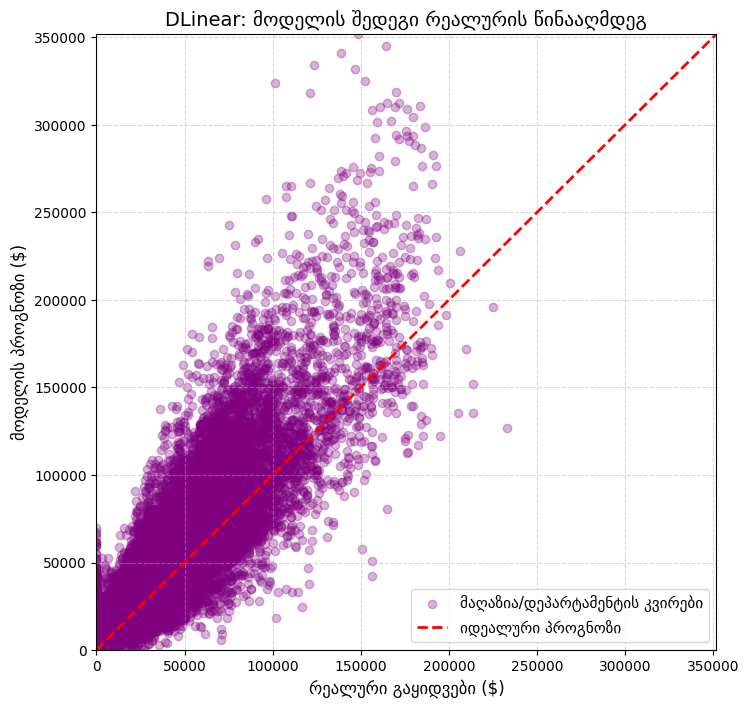

✅ მეტრიკები და სკატერ პლოტი წარმატებით აიტვირთა tsarc21-ის აქტიურ რანში (ID: f08690d84c6a440d8a9254ebc6dd3b9c)!
🏃 View run DLinear_Final_Hyperparameter_Tuning at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1/runs/f08690d84c6a440d8a9254ebc6dd3b9c
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/1


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from sklearn.metrics import r2_score, mean_absolute_error

# 1. მონაცემების მომზადება (ვიღებთ წინა სელის შედეგს და ვამატებთ დღესასწაულების ინფორმაციას ორიგინალიდან)
original_train_sub = train_df[['unique_id', 'ds', 'IsHoliday']].drop_duplicates()
cv_eval_final = pd.merge(cv_final_df, original_train_sub, on=['unique_id', 'ds'], how='left')
cv_eval_final['Weight'] = np.where(cv_eval_final['IsHoliday'] == True, 5, 1)

actuals = cv_eval_final['y'].values
predictions = cv_eval_final['DLinear'].values
weights = cv_eval_final['Weight'].values

# 2. რიცხვითი პარამეტრების გამოთვლა
r2 = r2_score(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)

holiday_mask = cv_eval_final['IsHoliday'] == True
mae_holidays = mean_absolute_error(actuals[holiday_mask], predictions[holiday_mask])
mae_regular = mean_absolute_error(actuals[~holiday_mask], predictions[~holiday_mask])

# ხელახლა გამოვთვალოთ საბოლოო WMAE ცვლადი უსაფრთხოებისთვის
absolute_errors_final = np.abs(actuals - predictions)
wmae_final = np.sum(weights * absolute_errors_final) / np.sum(weights)

print("==================================================")
print("📊 DLINEAR მოდელის დასწავლის რიცხვითი პარამეტრები:")
print("==================================================")
print(f"📈 R² Score (Variance Explained): {r2:.4f} ({r2*100:.2f}%-ს ხსნის მოდელი)")
print(f"📉 საერთო MAE (საშუალო ცდომილება): ${mae:.2f}")
print(f"🎄 დღესასწაულების კვირის MAE: ${mae_holidays:.2f}")
print(f"📅 ჩვეულებრივი კვირის MAE: ${mae_regular:.2f}")
print(f"🏆 საბოლოო WMAE (Kaggle Score): ${wmae_final:.2f}")
print("==================================================")

# 3. ვიზუალური გრაფიკის აგება (Scatter Plot)
plt.figure(figsize=(8, 8))
plt.scatter(actuals, predictions, alpha=0.3, color='purple', label='მაღაზია/დეპარტამენტის კვირები')

# იდეალური პროგნოზის ხაზი (y = x)
max_val = max(max(actuals), max(predictions))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='იდეალური პროგნოზი')

plt.title('DLinear: მოდელის შედეგი რეალურის წინააღმდეგ', fontsize=14)
plt.xlabel('რეალური გაყიდვები ($)', fontsize=12)
plt.ylabel('მოდელის პროგნოზი ($)', fontsize=12)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# გრაფიკის შენახვა
metrics_plot_path = 'dlinear_metrics_scatter.png'
plt.savefig(metrics_plot_path, bbox_inches='tight')
plt.show()

# 4. ლოგირება MLflow-ში (ბოლო აქტიურ რანში ხელით ჩაწერილი ID-ის გარეშე)
active_run = mlflow.last_active_run()

if active_run is not None:
    with mlflow.start_run(run_id=active_run.info.run_id):
        mlflow.log_metric("r2_score", r2)
        mlflow.log_metric("mae_holidays", mae_holidays)
        mlflow.log_metric("mae_regular", mae_regular)
        mlflow.log_artifact(metrics_plot_path, artifact_path="plots")
        print(f"✅ მეტრიკები და სკატერ პლოტი წარმატებით აიტვირთა tsarc21-ის აქტიურ რანში (ID: {active_run.info.run_id})!")
else:
    print("⚠️ აქტიური რანი ვერ მოიძებნა. დარწმუნდით, რომ ტრენინგის სელი წარმატებით დასრულდა.")

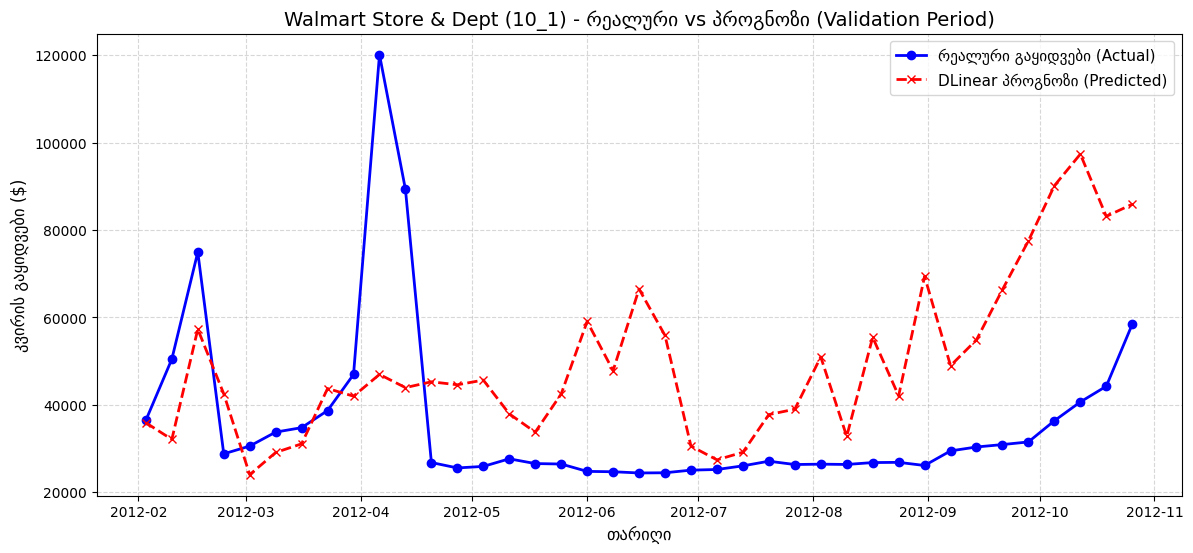

✅ პირველი გრაფიკი (dlinear_actual_vs_pred.png) წარმატებით შეინახა!


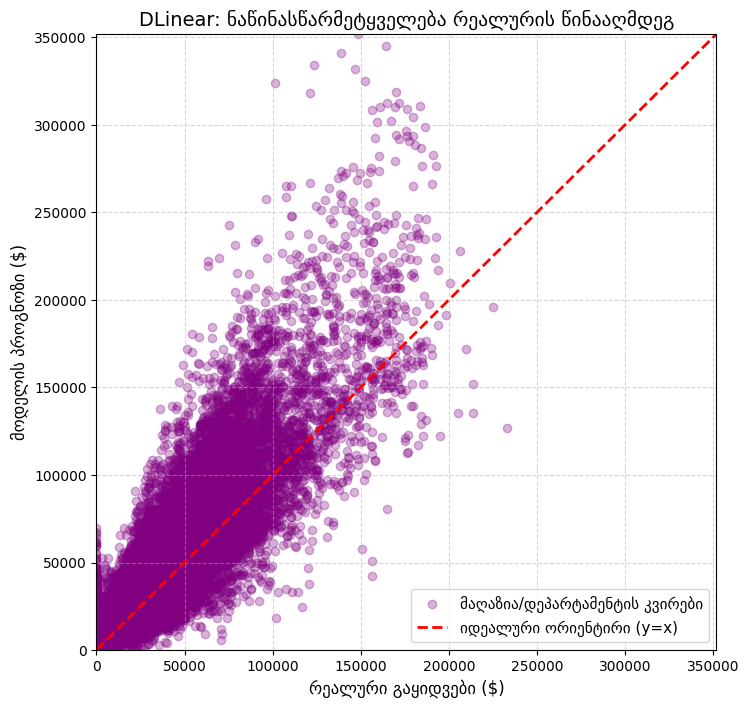

✅ მეორე გრაფიკი (dlinear_metrics_scatter.png) წარმატებით შეინახა!


In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

sample_id = cv_final_df['unique_id'].iloc[0]
sample_df = cv_final_df[cv_final_df['unique_id'] == sample_id].sort_values('ds')

plt.figure(figsize=(14, 6))
plt.plot(sample_df['ds'], sample_df['y'], label='რეალური გაყიდვები (Actual)', color='blue', marker='o', linewidth=2)
plt.plot(sample_df['ds'], sample_df['DLinear'], label='DLinear პროგნოზი (Predicted)', color='red', linestyle='--', marker='x', linewidth=2)

plt.title(f'Walmart Store & Dept ({sample_id}) - რეალური vs პროგნოზი (Validation Period)', fontsize=14)
plt.xlabel('თარიღი', fontsize=12)
plt.ylabel('კვირის გაყიდვები ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('dlinear_actual_vs_pred.png', bbox_inches='tight')
plt.show()

print("✅ პირველი გრაფიკი (dlinear_actual_vs_pred.png) წარმატებით შეინახა!")



actuals = cv_eval_final['y'].values
predictions = cv_eval_final['DLinear'].values

plt.figure(figsize=(8, 8))
plt.scatter(actuals, predictions, alpha=0.3, color='purple', label='მაღაზია/დეპარტამენტის კვირები')

max_val = max(max(actuals), max(predictions))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='იდეალური ორიენტირი (y=x)')

plt.title('DLinear: ნაწინასწარმეტყველება რეალურის წინააღმდეგ', fontsize=14)
plt.xlabel('რეალური გაყიდვები ($)', fontsize=12)
plt.ylabel('მოდელის პროგნოზი ($)', fontsize=12)
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.savefig('dlinear_metrics_scatter.png', bbox_inches='tight')
plt.show()

print("✅ მეორე გრაფიკი (dlinear_metrics_scatter.png) წარმატებით შეინახა!")